<a href="https://colab.research.google.com/github/harinathreddy-ai/Python-for-ai/blob/main/Decision_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees


# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn import metrics


# Downloading the Data

In [22]:
path= 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
df=pd.read_csv(path)
df.sample(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
7,41,M,LOW,HIGH,11.037,drugC
108,72,M,HIGH,NORMAL,9.677,drugB
46,37,F,HIGH,HIGH,13.091,drugA
104,22,M,HIGH,NORMAL,28.294,drugY
193,72,M,LOW,HIGH,6.769,drugC


# Data Analysis and pre-processing

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [23]:
label_encoder=LabelEncoder()
df['Sex']=label_encoder.fit_transform(df['Sex'])
df['BP']=label_encoder.fit_transform(df['BP'])
df['Cholesterol']=label_encoder.fit_transform(df['Cholesterol'])
#df['Drug']=label_encoder.fit_transform(df['Drug'])
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY
...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC
196,16,1,1,0,12.006,drugC
197,52,1,2,0,9.894,drugX
198,23,1,2,1,14.020,drugX


In [24]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [25]:
custom_map={'drugA':0,'drugB':1,'drugC':2,'drugX':3,'drugY':4}
df['Drug_num']=df['Drug'].map(custom_map)
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Drug_num
0,23,0,0,0,25.355,drugY,4
1,47,1,1,0,13.093,drugC,2
2,47,1,1,0,10.114,drugC,2
3,28,0,2,0,7.798,drugX,3
4,61,0,1,0,18.043,drugY,4
...,...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC,2
196,16,1,1,0,12.006,drugC,2
197,52,1,2,0,9.894,drugX,3
198,23,1,2,1,14.020,drugX,3


In [27]:
df.drop(columns=['Drug']).corr()['Drug_num']

,Drug_num
Age,-0.004828
Sex,-0.098573
BP,0.372868
Cholesterol,0.055629
Na_to_K,0.589120
Drug_num,1.000000


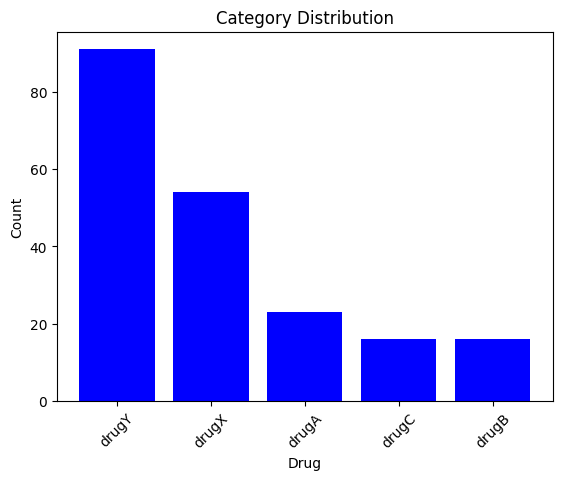

In [31]:
category_counts=df['Drug'].value_counts()
plt.bar(category_counts.index, category_counts.values, color='blue')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.title('Category Distribution')
plt.xticks(rotation=45)  # Rotate labels for better readability if needed
plt.show()

# Building Model

In [33]:
y=df['Drug']
x=df.drop(['Drug','Drug_num'],axis=1)

In [34]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=32)

In [35]:
drugtree=DecisionTreeClassifier(criterion='entropy',max_depth=4)
drugtree.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

# Evaluation

In [36]:
drugpred=drugtree.predict(x_test)

In [38]:
print("Decision Trees's Accuracy: ", metrics.accuracy_score(y_test, drugpred))

Decision Trees's Accuracy:  1.0


# Visualize the tree

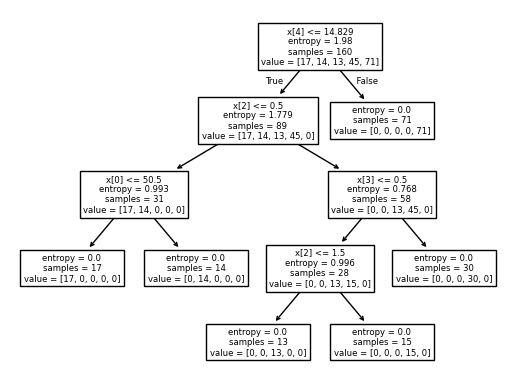

In [39]:
plot_tree(drugtree)
plt.show()